1.LOAD DATASET

In [2]:
import pandas as pd

PLATFORM = "Youtube"

train_df = pd.read_csv(
    "../data_preprocess/processed_data/ml_data/youtube_train.csv"
)

test_df = pd.read_csv(
    "../data_preprocess/processed_data/ml_data/youtube_test.csv"
)

print(train_df.shape)
print(test_df.shape)

(14504, 56)
(3626, 56)


In [3]:
# --- CODE FOR VIEWING POPULARITY VALUES HERE ---
print("\n" + "="*30)
print("Class distribution in the training set")
print("="*30)
print(train_df["popularity"].value_counts())
print("\nRatio %:")
print(train_df["popularity"].value_counts(normalize=True) * 100)

print("\n" + "="*30)
print("Class distribution in the test set")
print("="*30)
print(test_df["popularity"].value_counts())
print("\nRatio %:")
print(test_df["popularity"].value_counts(normalize=True) * 100)


Class distribution in the training set
popularity
0    11602
1     2902
Name: count, dtype: int64

Ratio %:
popularity
0    79.991726
1    20.008274
Name: proportion, dtype: float64

Class distribution in the test set
popularity
0    2901
1     725
Name: count, dtype: int64

Ratio %:
popularity
0    80.005516
1    19.994484
Name: proportion, dtype: float64


In [4]:
# 1. Calculate the Ratio for scale_pos_weight
negative_count = train_df["popularity"].value_counts()[0]
positive_count = train_df["popularity"].value_counts()[1]

ratio = negative_count / positive_count
print(f"Anti-lazy activated! scale_pos_weight = {ratio:.2f}")

Anti-lazy activated! scale_pos_weight = 4.00


In [6]:
X_train = train_df.drop(
    columns=[
        "post_id",
        "user_id",
        "popularity"
    ]
)
y_train = train_df["popularity"]

X_test = test_df.drop(
    columns=[
        "post_id",
        "user_id",
        "popularity"
    ]
)
y_test = test_df["popularity"]

In [7]:
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# 2. Create XGBoost model with Combo: Anti-lazy (Ratio) + Anti-overfitting (Colsample)
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=ratio,     # Handle imbalanced data
    n_estimators=500,           # Number of boosting rounds
    learning_rate=0.02,         # Step size shrinkage
    max_depth=6,                # Maximum tree depth
    min_child_weight=1,         # Minimum sum of instance weight
    gamma=0.1,                  # Minimum loss reduction
    subsample=0.8,              # Fraction of training data per tree
    colsample_bytree=0.5,       # Fraction of features per tree
    random_state=42,            # For reproducibility
    n_jobs=-1                   # Use all CPU cores
)

In [8]:
print("\n" + "=" * 60)
print("TRAINING XGBOOST...")
print("=" * 60)

model.fit(
    X_train,
    y_train
)


TRAINING XGBOOST...


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.5
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [9]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]


In [10]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

In [11]:
print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred
    )
)
print(f"ROC-AUC  : {roc_auc:.4f}")


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.94      0.83      0.88      2901
           1       0.53      0.78      0.63       725

    accuracy                           0.82      3626
   macro avg       0.74      0.81      0.76      3626
weighted avg       0.86      0.82      0.83      3626

ROC-AUC  : 0.8965


In [12]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print(cm)


CONFUSION MATRIX
[[2401  500]
 [ 156  569]]


In [13]:
importance_df = pd.DataFrame({

    "feature": X_train.columns,
    "importance": model.feature_importances_

})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print("\n" + "=" * 60)
print("TOP 15 IMPORTANT FEATURES")
print("=" * 60)

print(
    importance_df.head(15)
)


TOP 15 IMPORTANT FEATURES
                feature  importance
3             followers    0.247543
5              verified    0.122122
21        topic_Climate    0.015308
10       toxicity_score    0.014939
27         topic_Gaming    0.014825
25        topic_Finance    0.014606
39    language_Japanese    0.014509
30        topic_Science    0.014120
52     location_Unknown    0.014116
6        content_length    0.014007
18  sentiment_intensity    0.013985
44      media_type_Poll    0.013750
9    sentiment_negative    0.013737
29       topic_Politics    0.013685
8    sentiment_positive    0.013668


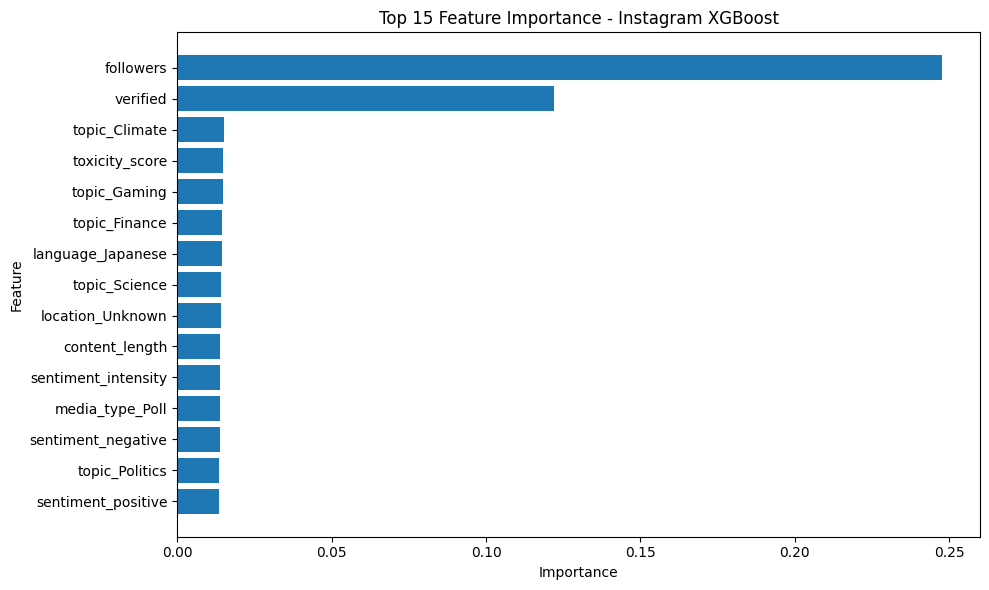

In [14]:
import matplotlib.pyplot as plt
top_n = 15

plot_df = importance_df.head(top_n)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["feature"][::-1],
    plot_df["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Top 15 Feature Importance - Instagram XGBoost"
)

plt.tight_layout()

plt.show()